# Tarea 2 -- Modelo de propension: pension_plan

easyMoney - TFM Nuclio Digital School

Este notebook entrena y evalua un modelo de propension a la compra de `pension_plan`, el producto con mayor margen (79% del margen total, segun la Tarea 1). Parte del panel guardado por `02_preprocessing_propension.ipynb`.

Resumen del enfoque:
- Target: adquisicion nueva (el cliente no tenia el producto el mes anterior y lo tiene este mes).
- Features: lag-1 de variables demograficas y de actividad (nunca datos del mes actual, para evitar leakage).
- Split temporal estricto: train / test (penultimo mes) / validacion (ultimo mes).
- Modelo: arbol de decision con `class_weight='balanced'` (el target esta muy desbalanceado).
- Evaluacion: metricas tecnicas (classification_report, matriz de confusion, ROC/AUC con `predict_proba`) + una metrica de negocio (conversion real si se contacta al top 5% de clientes por probabilidad).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

df_panel = pd.read_parquet('data/df_panel_propension.parquet', engine='pyarrow')
print(df_panel.shape)

(5961849, 35)


## 1. Target: adquisicion nueva de pension_plan

`diff()` calcula, PARA CADA CLIENTE POR SEPARADO (gracias al `groupby`), la diferencia entre el valor de `pension_plan` de este mes y el del mes anterior:
- `0 -> 1` => `diff = 1` (adquisicion nueva: esto es lo que queremos detectar)
- `1 -> 1` => `diff = 0` (ya lo tenia, no es 'nuevo')
- `0 -> 0` => `diff = 0` (sigue sin tenerlo)
- primer mes de cada cliente => `diff = NaN` (no hay mes anterior, se descarta mas adelante)

In [2]:
df_panel['target'] = df_panel.groupby('pk_cid')['pension_plan'].diff()
df_panel['target'] = df_panel['target'].apply(lambda x: 1 if x == 1 else 0)

print(df_panel['target'].value_counts())
print(f"Total de adquisiciones nuevas de pension_plan: {df_panel['target'].sum()}")

target
0    5924994
1      36855
Name: count, dtype: int64
Total de adquisiciones nuevas de pension_plan: 36855


## 2. Nuevas Features

Features que usa este modelo (todas en su version `_lag1`, es decir, el valor del mes anterior). No incluimos `em_acount_lag1` aqui porque no lo validamos como feature en este modelo -- se puede anadir mas adelante como mejora. Filtramos a clientes que el mes anterior NO tenian `pension_plan` (los unicos que pueden generar un target=1 real, y a los unicos que tendria sentido ofrecerles el producto) y quitamos el primer mes de cada cliente (sin lag disponible).

In [3]:
features_base = ['age', 'salary', 'gender', 'segment', 'entry_channel',
                  'active_customer', 'num_products']
lag_cols_necesarias = [f'{c}_lag1' for c in features_base] + ['pension_plan_lag1']

df_model = df_panel.dropna(subset=lag_cols_necesarias).copy()
df_model = df_model[df_model['pension_plan_lag1'] == 0].copy()

print('Filas en el panel completo:', df_panel.shape[0])
print('Filas tras quitar primer mes y filtrar elegibles:', df_model.shape[0])
print(df_model['target'].value_counts())

Filas en el panel completo: 5961849
Filas tras quitar primer mes y filtrar elegibles: 5305179
target
0    5268324
1      36855
Name: count, dtype: int64


In [ ]:
df_model.head()

## 3. Split temporal (train / test / validacion)

Cortamos por fecha, no de forma aleatoria: como los datos son un panel temporal (mismos clientes repetidos mes a mes), un split aleatorio filtraria informacion del futuro al pasado. El ultimo mes disponible se reserva para validacion, el penultimo para test, y el resto para entrenar.

In [4]:
meses = sorted(df_model['pk_partition'].unique())
mes_val = meses[-1]
mes_test = meses[-2]
print('Mes de test:', mes_test, '| Mes de validacion:', mes_val)

train = df_model[df_model['pk_partition'] < mes_test]
test = df_model[df_model['pk_partition'] == mes_test]
val = df_model[df_model['pk_partition'] == mes_val]

print('Train:', train.shape)
print('Test: ', test.shape)
print('Val:  ', val.shape)

Mes de test: 2019-04-01 00:00:00 | Mes de validacion: 2019-05-01 00:00:00
Train: (4464025, 36)
Test:  (418993, 36)
Val:   (422161, 36)


## 4. Codificacion de variables

`entry_channel` tiene decenas de categorias raras que apenas se repiten y solo meten ruido en un modelo sencillo -- las agrupamos en 'Otros' (calculando la frecuencia SOLO con train, para no filtrar informacion de test/val). Despues aplicamos One-Hot Encoding a las variables categoricas.

In [5]:
frecuencias = train['entry_channel_lag1'].value_counts(normalize=True)
categorias_frecuentes = frecuencias[frecuencias >= 0.01].index

def agrupar_entry_channel(serie):
    return serie.where(serie.isin(categorias_frecuentes), 'Otros')

train = train.copy()
test = test.copy()
val = val.copy()
train['entry_channel_lag1'] = agrupar_entry_channel(train['entry_channel_lag1'])
test['entry_channel_lag1']  = agrupar_entry_channel(test['entry_channel_lag1'])
val['entry_channel_lag1']   = agrupar_entry_channel(val['entry_channel_lag1'])

print('Categorias de entry_channel tras agrupar:', train['entry_channel_lag1'].nunique())

cat_cols = ['gender_lag1', 'segment_lag1', 'entry_channel_lag1']
num_cols = ['age_lag1', 'salary_lag1', 'active_customer_lag1', 'num_products_lag1']

X_train = pd.get_dummies(train[num_cols + cat_cols], columns=cat_cols)
X_test  = pd.get_dummies(test[num_cols + cat_cols], columns=cat_cols)
X_val   = pd.get_dummies(val[num_cols + cat_cols], columns=cat_cols)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

y_train = train['target']
y_test = test['target']
y_val = val['target']

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print('X_val:  ', X_val.shape)

Categorias de entry_channel tras agrupar: 11
X_train: (4464025, 21)
X_test:  (418993, 21)
X_val:   (422161, 21)


## 5. Modelo

Arbol de decision poco profundo (`max_depth=5`, interpretable) con `class_weight='balanced'`: el propio modelo compensa que solo un ~0.7% del train sea target=1, dandole mas peso a esos casos en vez de tirar datos (como haria un undersampling).

In [6]:
modelo = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
modelo.fit(X_train, y_train)
print('Modelo entrenado correctamente.')

Modelo entrenado correctamente.


## 6. Evaluacion tecnica (sobre el mes de test)

OJO: la curva ROC/AUC se calcula con `predict_proba` (probabilidad continua), nunca con `predict` (0/1 ya decidido) -- ese fue justo el bug que encontramos en uno de los notebooks de referencia de otros anos.

              precision    recall  f1-score   support

   No compra       1.00      0.73      0.84    416719
      Compra       0.02      0.87      0.03      2274

    accuracy                           0.73    418993
   macro avg       0.51      0.80      0.44    418993
weighted avg       0.99      0.73      0.84    418993



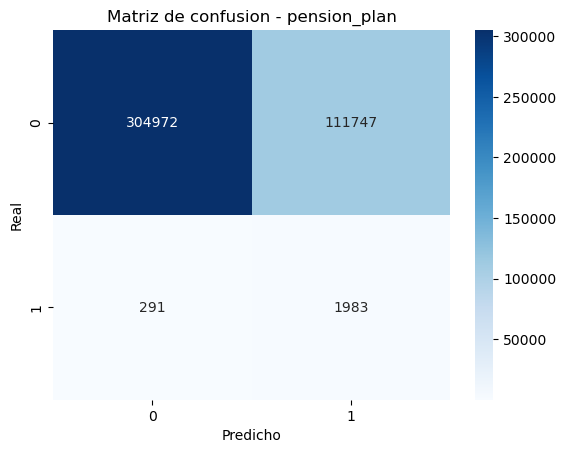

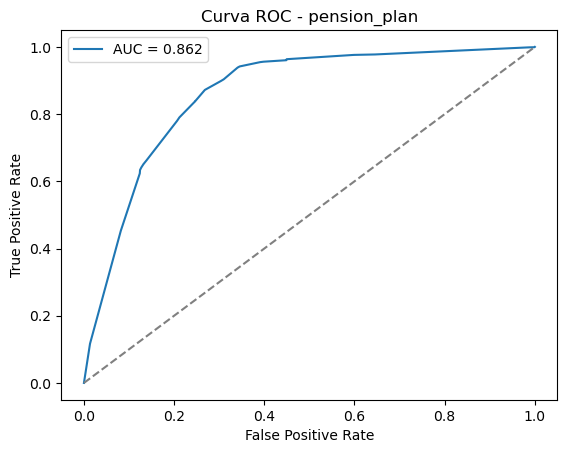

In [7]:
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['No compra', 'Compra']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusion - pension_plan')
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - pension_plan')
plt.legend()
plt.show()

## 7. Evaluacion de negocio: conversion real en el top 5%

En la practica, no se contacta a todo el mundo que el modelo marca con el corte por defecto (0.5) -- se ordena a los clientes por probabilidad y se contacta a un porcentaje pequeno de arriba. Aqui comprobamos, sobre el mes de VALIDACION (el unico mes que no hemos tocado para nada mas), que conversion real se conseguiria si Carol solo pudiera contactar al 5% de la base.

In [8]:
val_proba = modelo.predict_proba(X_val)[:, 1]

df_sim = pd.DataFrame({
    'pk_cid': val['pk_cid'].values,
    'probabilidad': val_proba,
    'compra_real': y_val.values
}).sort_values(by='probabilidad', ascending=False)

top_pct = 0.05
top_n = int(len(df_sim) * top_pct)
top_clientes = df_sim.head(top_n)

compras_en_top = top_clientes['compra_real'].sum()
tasa_conversion_top = compras_en_top / top_n
tasa_base = df_sim['compra_real'].mean()

print(f'Clientes evaluados en validacion: {len(df_sim)}')
print(f'Clientes en el top {top_pct*100:.0f}%: {top_n}')
print(f'Compras reales dentro del top: {compras_en_top}')
print(f'Tasa de conversion en el top {top_pct*100:.0f}%: {tasa_conversion_top*100:.2f}%')
print(f'Tasa de conversion si contactases al azar: {tasa_base*100:.2f}%')
print(f'El modelo mejora la conversion x{tasa_conversion_top/tasa_base:.1f} frente a contactar al azar')

Clientes evaluados en validacion: 422161
Clientes en el top 5%: 21108
Compras reales dentro del top: 877
Tasa de conversion en el top 5%: 4.15%
Tasa de conversion si contactases al azar: 0.66%
El modelo mejora la conversion x6.3 frente a contactar al azar


## Resumen de resultados (pension_plan)

- AUC (test): 0.862
- Recall clase Compra (test): 0.87
- Precision clase Compra (test): 0.02 (esperable dado el desbalanceo extremo; no es la metrica relevante para el uso real del modelo)
- Conversion real en el top 5% (validacion): 4.15%, frente a 0.66% al azar -> x6.3
- El top 5% (21.108 clientes) captura 877 de los 2.791 compradores reales de mayo 2019 (~31% de todos los compradores reales, contactando solo al 5% de la base).

## 8. Scoring final: clientes reales a contactar hoy

Todo lo anterior evaluaba el modelo contra meses ya conocidos. Aquí lo aplicamos
de verdad: cogemos el estado de cada cliente en el último mes disponible y
predecimos su propensión para el mes siguiente (uno que todavía no ha pasado).

In [9]:
# Último mes disponible: tratamos sus valores como el "mes anterior" al que
# todavía no existe en los datos (el mes que viene)
ultimo_mes = df_model['pk_partition'].max()
df_actual = df_panel[df_panel['pk_partition'] == ultimo_mes].copy()

# Solo clientes que HOY no tienen pension_plan
df_actual = df_actual[df_actual['pension_plan'] == 0].copy()

# Agrupamos entry_channel con las mismas categorías frecuentes que usamos en el modelo
df_actual['entry_channel'] = df_actual['entry_channel'].where(
    df_actual['entry_channel'].isin(categorias_frecuentes), 'Otros'
)

# Mismas columnas que vio el modelo en el entrenamiento (renombradas a "_lag1"
# porque, desde el punto de vista del modelo, representan "el mes anterior")
X_actual = pd.get_dummies(
    df_actual[['age', 'salary', 'active_customer', 'num_products', 'gender', 'segment', 'entry_channel']]
    .rename(columns={
        'age': 'age_lag1', 'salary': 'salary_lag1',
        'active_customer': 'active_customer_lag1', 'num_products': 'num_products_lag1',
        'gender': 'gender_lag1', 'segment': 'segment_lag1', 'entry_channel': 'entry_channel_lag1'
    }),
    columns=['gender_lag1', 'segment_lag1', 'entry_channel_lag1']
)
X_actual = X_actual.reindex(columns=X_train.columns, fill_value=0)

proba_actual = modelo.predict_proba(X_actual)[:, 1]

df_scoring = pd.DataFrame({
    'pk_cid': df_actual['pk_cid'].values,
    'probabilidad_pension_plan': proba_actual
}).sort_values(by='probabilidad_pension_plan', ascending=False).reset_index(drop=True)

print(f'Clientes elegibles para pension_plan hoy: {len(df_scoring)}')
print(df_scoring.head(20))

df_scoring.to_csv('data/scoring_pension_plan.csv', index=False)
print('Guardado en data/scoring_pension_plan.csv')

Clientes elegibles para pension_plan hoy: 425556
     pk_cid  probabilidad_pension_plan
0   1097934                   0.906471
1   1005321                   0.906471
2   1123666                   0.906471
3   1477448                   0.906471
4   1374196                   0.906471
5   1005302                   0.906471
6   1123673                   0.906471
7   1021617                   0.906471
8   1005290                   0.906471
9   1384007                   0.906471
10  1189322                   0.906471
11  1005259                   0.906471
12  1005252                   0.906471
13  1243395                   0.906471
14  1083865                   0.906471
15  1243390                   0.906471
16  1116120                   0.906471
17  1058817                   0.906471
18  1172124                   0.906471
19  1420480                   0.906471
Guardado en data/scoring_pension_plan.csv
